In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv('/content/housing.csv')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.shape

(20640, 10)

In [4]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [8]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].median()
)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [11]:
df = pd.get_dummies(
    df,
    columns=['ocean_proximity'],
    dtype=int
)

In [12]:
df.shape

(20640, 14)

In [13]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [14]:
print(X.shape)

(20640, 13)


In [15]:
print(y.shape)

(20640,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 13)
(4128, 13)
(16512,)
(4128,)


In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()
model.add(
    Dense(
        1000,
        activation='relu',
        input_shape=(X_train.shape[1],)
    )
)


In [19]:
model = Sequential([

    # input layer
    Dense(1000, input_shape=(X_train.shape[1],), activation='relu'),

    # two hidden layers
    Dense(500, activation='relu'),
    Dense(250, activation='relu'),

    # output layer
    Dense(1, activation='linear')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │        14,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 250)            │       125,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 640,001 (2.44 MB)

 Trainable params: 640,001 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='rmsprop',
    loss='mse',
    metrics=['mae']
)

es = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=50,
    restore_best_weights=True
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    callbacks=[es],
    epochs=10,
    batch_size=50,
    verbose=1
)

Epoch 1/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 22231408640.0000 - mae: 112084.1562 - val_loss: 8219314688.0000 - val_mae: 71589.7812
Epoch 2/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 7208267264.0000 - mae: 64653.7617 - val_loss: 6110674432.0000 - val_mae: 56503.9062
Epoch 3/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 5520432128.0000 - mae: 54712.4219 - val_loss: 5602159616.0000 - val_mae: 51261.3086
Epoch 4/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5169902080.0000 - mae: 52154.9688 - val_loss: 5219606016.0000 - val_mae: 51757.8477
Epoch 5/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 5076867584.0000 - mae: 51528.7070 - val_loss: 5172089344.0000 - val_mae: 52252.1484
Epoch 6/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 5002590720.0000 - mae: 50960.4102 - val_loss: 5099003392.0000 - val_mae: 50545.4297
Epoch 7/10
331/331 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 4940711424.0000 - mae: 50541.1133 - val_loss: 5112336896.0000 - val

In [22]:
y_pred = model.predict(X_test).flatten()

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 50708.12905103107
MSE: 4913419384.146727
RMSE: 70095.78720684095
R2 Score: 0.625046877293032


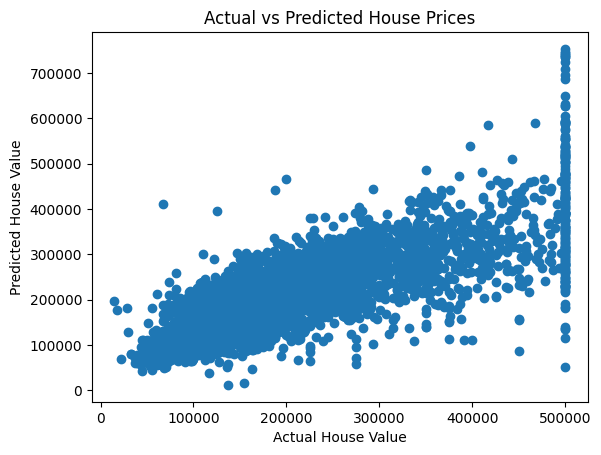

In [24]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Prices")

plt.show()

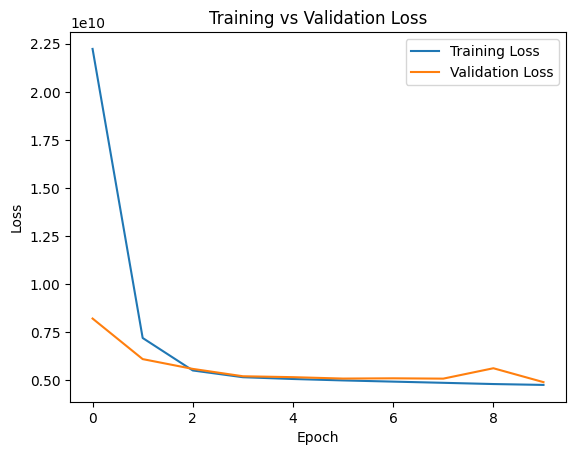

In [25]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [26]:
model.save('model_ann.h5')

In [27]:
import joblib

joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [28]:
import os

os.makedirs("templates", exist_ok=True)
os.makedirs("static", exist_ok=True)

In [29]:
model.save('model_ann.keras')

In [30]:
model.save_weights("model_weights.weights.h5")